# Agencia Lupa: spider-level EDA

Fixed sections:
1. Run selection and player evidence
2. Volume, temporal coverage, and quality overview
3. Text-length histograms by original_label and standard_label
4. Category, topic/tag, and temporal distribution
5. Missing fields and invalid dates
6. Cleaning and normalization review
7. NLP with stop-word removal, lemmas, and NER
8. Processed JSONL export


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display


def _find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().resolve().parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Repositorio nao encontrado a partir do diretorio atual.")


REPO_ROOT = _find_repo_root()
for path in (REPO_ROOT, REPO_ROOT / "src", REPO_ROOT / "notebooks"):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

import eda_utils as eu

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 160)
sns.set_theme(style="whitegrid", palette="crest")

## Run selection and player evidence

In [2]:
SPIDER = "agencia_lupa"
PLAYER = "Agencia Lupa"
DATA_DIR = eu.resolve_data_dir(str(REPO_ROOT / "data"))
SNAPSHOT_ID = None
BATCH_SIZE = 64

selection = eu.select_spider_run(DATA_DIR, SPIDER)
profile = eu.get_spider_profile(SPIDER)
display(eu.selection_to_frame(selection))
profile

,spider,agency_id,agency_name,selected_run_id,latest_run_id,latest_valid_run_id,fallback_applied,selection_reason,cleaning_flags,diagnostic_run_ids
0,agencia_lupa,agencia_lupa,Agencia Lupa,20260315T160713Z-77601f60,20260315T160713Z-77601f60,20260315T160713Z-77601f60,False,latest_valid_run,"html_unescape, unicode_normalize, collapse_whitespace, light_encoding_fix",


SpiderProfile(spider='agencia_lupa', display_name='Agencia Lupa', analysis_field_order=('title', 'claim', 'summary'), ignored_analysis_titles=frozenset(), dropped_export_titles=frozenset(), extract_label_prefix_before_colon=False, diagnostic_run_ids=(), cleaning_flags=('html_unescape', 'unicode_normalize', 'collapse_whitespace', 'light_encoding_fix'))

In [3]:
runs_df = eu.load_runs_df(DATA_DIR)
spider_runs = runs_df.loc[runs_df["spider"] == SPIDER].sort_values(
    "run_started_at", ascending=False
)
evidence_cols = [
    "run_id",
    "run_started_at",
    "run_finished_at",
    "items_seen",
    "items_stored",
    "items_deduped",
    "items_invalid",
    "has_items_file",
    "is_valid",
]
display(spider_runs[evidence_cols].head(10))

diagnostic_df = eu.diagnostic_runs_df(DATA_DIR, SPIDER)
if not diagnostic_df.empty:
    print("Diagnostic runs configured for this spider:")
    display(diagnostic_df[evidence_cols])

,run_id,run_started_at,run_finished_at,items_seen,items_stored,items_deduped,items_invalid,has_items_file,is_valid
31,20260315T160713Z-77601f60,2026-03-15 16:07:13+00:00,2026-03-15 16:07:49+00:00,1275,1275,0,0,True,True
30,20260315T160456Z-5bceb9f6,2026-03-15 16:04:56+00:00,2026-03-15 16:05:11+00:00,0,0,0,0,False,False
29,20260315T160244Z-064e5d9a,2026-03-15 16:02:45+00:00,2026-03-15 16:03:01+00:00,4,4,0,0,True,True
13,20260315T010005Z-1d265f16,2026-03-15 01:00:05+00:00,2026-03-15 07:03:08+00:00,4,4,0,0,True,True


## Volume, temporal coverage, and quality overview

In [4]:
nlp = eu.load_nlp_model()
raw_df = eu.load_spider_items_df(DATA_DIR, SPIDER, selection.selected_run_id)
selection, processed_records = eu.build_processed_records(
    DATA_DIR,
    SPIDER,
    selection=selection,
    nlp=nlp,
    batch_size=BATCH_SIZE,
)
processed_df = eu.processed_records_to_df(processed_records)
processed_df["published_at_dt"] = pd.to_datetime(
    processed_df["published_at"], utc=True, errors="coerce"
)

overview = pd.DataFrame(
    [
        {
            "player": PLAYER,
            "selected_run_id": selection.selected_run_id,
            "latest_run_id": selection.latest_run_id,
            "fallback_applied": selection.fallback_applied,
            "raw_rows": len(raw_df),
            "processed_rows": len(processed_df),
            "dropped_rows": len(raw_df) - len(processed_df),
            "coverage_start": processed_df["published_at_dt"].min(),
            "coverage_end": processed_df["published_at_dt"].max(),
            "invalid_dates": int(processed_df["published_at_dt"].isna().sum()),
            "missing_original_label": int(processed_df["original_label"].isna().sum()),
        }
    ]
)
display(overview)
display(raw_df.head(3))
display(processed_df.head(3))

,player,selected_run_id,latest_run_id,fallback_applied,raw_rows,processed_rows,dropped_rows,coverage_start,coverage_end,invalid_dates,missing_original_label
0,Agencia Lupa,20260315T160713Z-77601f60,20260315T160713Z-77601f60,False,1275,1275,0,2015-12-01 19:29:10+00:00,2026-03-12 17:04:12+00:00,0,1221


,item_id,agency_id,agency_name,spider,source_url,canonical_url,title,published_at,collected_at,claim,summary,verdict,rating,language,country,topics,tags,entities,source_type,run_id,published_at_dt,collected_at_dt,lag_hours,title_len,claim_len,summary_len,canonical_host,source_equals_canonical
0,bb3b51af225a8f7d316e15c9775cc003dbaf181864f90dcc1f3811979d66b098,agencia_lupa,Agencia Lupa,agencia_lupa,https://www.agencialupa.org/noticias/2026/03/06/golpe-usa-nome-do-atacadao-em-falsa-promocao-de-r-1-mil-no-dia-da-mulher/,https://www.agencialupa.org/noticias/2026/03/06/golpe-usa-nome-do-atacadao-em-falsa-promocao-de-r-1-mil-no-dia-da-mulher,Golpe usa nome do Atacadão em falsa promoção de R$ 1 mil no Dia da Mulher,2026-03-06T18:39:58+00:00,2026-03-15T16:07:13+00:00,Golpe usa nome do Atacadão em falsa promoção de R$ 1 mil no Dia da Mulher,Mensagem em circulação no WhatsApp leva a site falso que usa nome da rede varejista; empresa afirma que promoção não existe,Falso,Falso,pt-BR,BR,"[Jornalismo, Notícias, Verificação]","[Atacadão, Dia da mulher, dia internacional da mulher, Golpe da promoção, Golpe do prêmio, Será que é Golpe]",[],NewsArticle,20260315T160713Z-77601f60,2026-03-06 18:39:58+00:00,2026-03-15 16:07:13+00:00,213.454167,73,73,123,www.agencialupa.org,0.0
1,52a61fd420c0a04b10d2b02677c41bc1b8bf1605eb1200f0c0a728ce1c7ca8c3,agencia_lupa,Agencia Lupa,agencia_lupa,https://www.agencialupa.org/jornalismo/2024/03/12/e-falso-aviso-sobre-golpe-cheiro-da-morte-para-dopar-pessoas-em-estacionamentos/,https://www.agencialupa.org/jornalismo/2024/03/12/e-falso-aviso-sobre-golpe-cheiro-da-morte-para-dopar-pessoas-em-estacionamentos,É falso aviso sobre golpe ‘cheiro da morte’ para dopar pessoas em estacionamentos,2024-03-12T19:29:09+00:00,2026-03-15T16:07:14+00:00,É falso aviso sobre golpe ‘cheiro da morte’ para dopar pessoas em estacionamentos,"Circula na internet um suposto informativo de segurança, de 28 de fevereiro de 2024, sobre um golpe chamado “cheiro da morte”, no qual criminosos abordam",Falso,Falso,pt-BR,BR,"[Jornalismo, Verificação]","[Atacadão, Carrefour, Extra, Falso, verificamos, Walmart]",[],NewsArticle,20260315T160713Z-77601f60,2024-03-12 19:29:09+00:00,2026-03-15 16:07:14+00:00,17588.634722,81,81,153,www.agencialupa.org,0.0
2,db7963f9a11a3cd1ac51fb99a63abbd143eb5da15ff7e65f3bc91978e9d4e684,agencia_lupa,Agencia Lupa,agencia_lupa,https://www.agencialupa.org/jornalismo/2025/10/01/e-falso-que-ivete-criticou-nikolas-ferreira-e-foi-expulsa-do-programa-do-ratinho/,https://www.agencialupa.org/jornalismo/2025/10/01/e-falso-que-ivete-criticou-nikolas-ferreira-e-foi-expulsa-do-programa-do-ratinho,É falso que Ivete criticou Nikolas Ferreira e foi expulsa do Programa do Ratinho,2025-10-01T14:23:42+00:00,2026-03-15T16:07:14+00:00,É falso que Ivete criticou Nikolas Ferreira e foi expulsa do Programa do Ratinho,Circula no Instagram um vídeo afirmando que a cantora Ivete Sangalo criticou o deputado federal Nikolas Ferreira (PL-MG) durante o Programa do Ratinho e,Falso,Falso,pt-BR,BR,"[Jornalismo, Verificação]","[Falso, Ivete Sangalo, Nikolas Ferreira, Política, Ratinho, verificamos]",[],NewsArticle,20260315T160713Z-77601f60,2025-10-01 14:23:42+00:00,2026-03-15 16:07:14+00:00,3961.725556,80,80,152,www.agencialupa.org,0.0


,record_id,source_record_id,dataset_id,source_url,published_at,language,title,author,subtitle,claim_text,body_text,analysis_text,text_for_ner,text_without_stopwords,lemmatized_text,original_label,standard_label,category,entities,variant,metadata.analysis_text_length,metadata.entity_count,metadata.spider,metadata.agency_id,metadata.agency_name,metadata.run_id,metadata.latest_run_id,metadata.fallback_applied,metadata.source_type,metadata.source_topics,metadata.source_tags,metadata.source_rating,published_at_dt
0,factcheck_scrape_agencia_lupa:bb3b51af225a8f7d316e15c9775cc003dbaf181864f90dcc1f3811979d66b098,bb3b51af225a8f7d316e15c9775cc003dbaf181864f90dcc1f3811979d66b098,factcheck_scrape_agencia_lupa,https://www.agencialupa.org/noticias/2026/03/06/golpe-usa-nome-do-atacadao-em-falsa-promocao-de-r-1-mil-no-dia-da-mulher/,2026-03-06T18:39:58+00:00,pt-BR,Golpe usa nome do Atacadão em falsa promoção de R$ 1 mil no Dia da Mulher,None,None,Golpe usa nome do Atacadão em falsa promoção de R$ 1 mil no Dia da Mulher,Mensagem em circulação no WhatsApp leva a site falso que usa nome da rede varejista; empresa afirma que promoção não existe,golpe usa nome do atacadão em falsa promoção de r$ 1 mil no dia da mulher mensagem em circulação no whatsapp leva a site falso que usa nome da rede varejist...,golpe usa nome do atacadão em falsa promoção de r$ 1 mil no dia da mulher mensagem em circulação no whatsapp leva a site falso que usa nome da rede varejist...,golpe nome atacadão falsa promoção r$ 1 dia mulher mensagem circulação whatsapp leva site falso nome rede varejista empresa afirma promoção existe,golpe usar nome de o atacadão em falso promoção de r$ 1 mil em o dia de o mulher mensagem em circulação em o whatsapp levar a site falso que usar nome de o ...,Falso,false,Jornalismo,"[{'text': 'r$', 'label': 'PER', 'start_char': 48, 'end_char': 50}, {'text': 'whatsapp', 'label': 'MISC', 'start_char': 100, 'end_char': 108}]",claim_summary,197,2,agencia_lupa,agencia_lupa,Agencia Lupa,20260315T160713Z-77601f60,20260315T160713Z-77601f60,False,NewsArticle,"[Jornalismo, Notícias, Verificação]","[Atacadão, Dia da mulher, dia internacional da mulher, Golpe da promoção, Golpe do prêmio, Será que é Golpe]",Falso,2026-03-06 18:39:58+00:00
1,factcheck_scrape_agencia_lupa:52a61fd420c0a04b10d2b02677c41bc1b8bf1605eb1200f0c0a728ce1c7ca8c3,52a61fd420c0a04b10d2b02677c41bc1b8bf1605eb1200f0c0a728ce1c7ca8c3,factcheck_scrape_agencia_lupa,https://www.agencialupa.org/jornalismo/2024/03/12/e-falso-aviso-sobre-golpe-cheiro-da-morte-para-dopar-pessoas-em-estacionamentos/,2024-03-12T19:29:09+00:00,pt-BR,É falso aviso sobre golpe ‘cheiro da morte’ para dopar pessoas em estacionamentos,None,None,É falso aviso sobre golpe ‘cheiro da morte’ para dopar pessoas em estacionamentos,"Circula na internet um suposto informativo de segurança, de 28 de fevereiro de 2024, sobre um golpe chamado “cheiro da morte”, no qual criminosos abordam","é falso aviso sobre golpe ‘cheiro da morte’ para dopar pessoas em estacionamentos circula na internet um suposto informativo de segurança, de 28 de fevereir...","é falso aviso sobre golpe ‘cheiro da morte’ para dopar pessoas em estacionamentos circula na internet um suposto informativo de segurança, de 28 de fevereir...",falso aviso golpe cheiro morte dopar pessoas estacionamentos circula internet suposto informativo segurança 28 fevereiro 2024 golpe chamado cheiro morte cri...,ser falso aviso sobre golpe cheiro de o morte para dopar pessoa em estacionamento circular em o internet um suposto informativo de segurança de 28 de fevere...,Falso,false,Jornalismo,[],claim_summary,235,0,agencia_lupa,agencia_lupa,Agencia Lupa,20260315T160713Z-77601f60,20260315T160713Z-77601f60,False,NewsArticle,"[Jornalismo, Verificação]","[Atacadão, Carrefour, Extra, Falso, verificamos, Walmart]",Falso,2024-03-12 19:29:09+00:00
2,factcheck_scrape_agencia_lupa:db7963f9a11a3cd1ac51fb99a63abbd143eb5da15ff7e65f3bc91978e9d4e684,db7963f9a11a3cd1ac51fb99a63abbd143eb5da15ff7e65f3bc91

## Text-length histograms by label

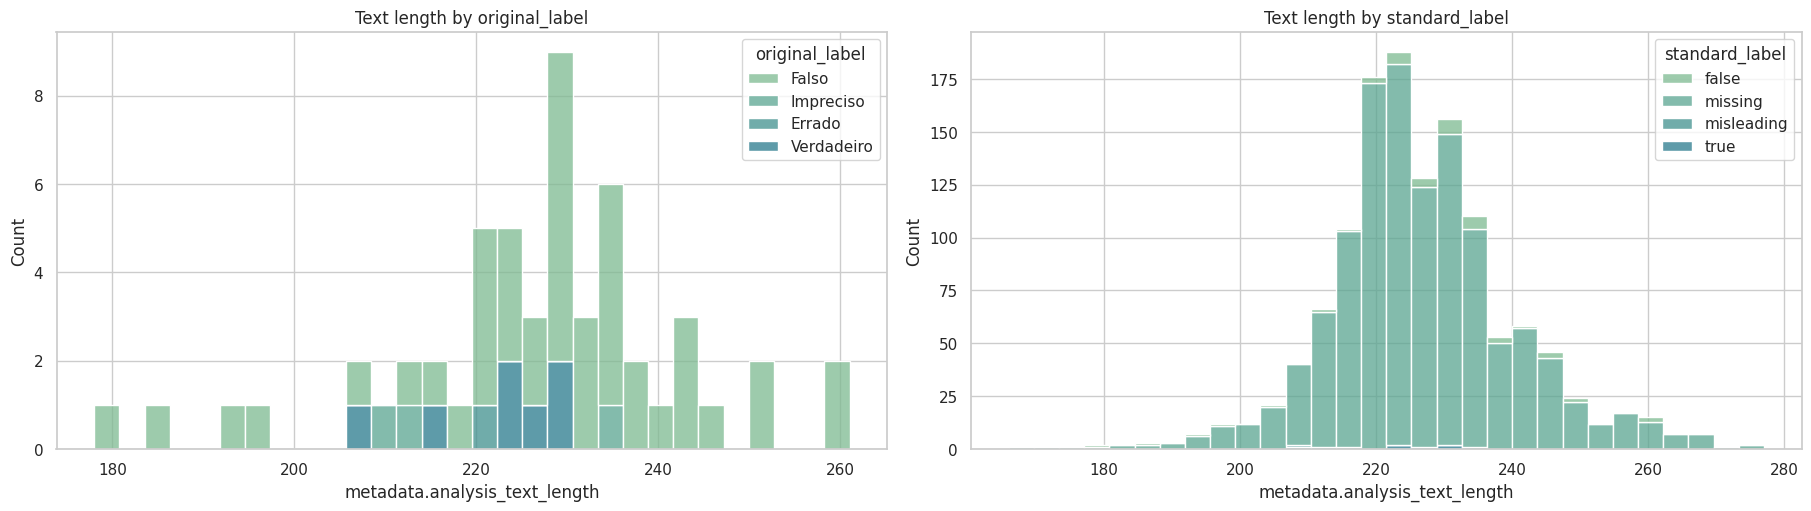

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)
sns.histplot(
    data=processed_df,
    x="metadata.analysis_text_length",
    hue="original_label",
    bins=30,
    multiple="stack",
    ax=axes[0],
)
axes[0].set_title("Text length by original_label")

sns.histplot(
    data=processed_df,
    x="metadata.analysis_text_length",
    hue="standard_label",
    bins=30,
    multiple="stack",
    ax=axes[1],
)
axes[1].set_title("Text length by standard_label")
plt.show()

## Category, topic/tag, temporal distribution, and data quality

In [6]:
topic_counts = raw_df["topics"].explode().dropna().value_counts().head(20)
tag_counts = raw_df["tags"].explode().dropna().value_counts().head(20)
category_counts = processed_df["category"].value_counts(dropna=False).head(20)

display(category_counts.rename_axis("category").reset_index(name="count"))
display(topic_counts.rename_axis("topic").reset_index(name="count"))
display(tag_counts.rename_axis("tag").reset_index(name="count"))

monthly = (
    processed_df.dropna(subset=["published_at_dt"])
    .assign(month=lambda df: df["published_at_dt"].dt.to_period("M").dt.to_timestamp())
    .groupby("month")
    .size()
    .reset_index(name="count")
)
display(monthly.tail(24))

missing_fields = (
    raw_df[["title", "claim", "summary", "verdict", "rating", "published_at"]]
    .isna()
    .sum()
    .rename_axis("field")
    .reset_index(name="missing_count")
)
display(missing_fields)

display(
    processed_df.loc[
        processed_df["published_at_dt"].isna(), ["source_record_id", "title", "published_at"]
    ].head(20)
)

,category,count
0,Checagem,1260
1,Jornalismo,10
2,Verificação,3
3,Reportagem,1
4,Notícias,1


,topic,count
0,Jornalismo,1270
1,Checagem,1260
2,Verificação,12
3,Notícias,5
4,Reportagem,3


,tag,count
0,Falso,736
1,Verdadeiro,705
2,Exagerado,530
3,Política,249
4,Eleições 2020,175
5,Rio de Janeiro,172
6,checagem,171
7,São Paulo,171
8,Jair Bolsonaro,155
9,PSDB,154


/tmp/ipykernel_2074193/1119197242.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(month=lambda df: df["published_at_dt"].dt.to_period("M").dt.to_timestamp())


,month,count
91,2024-01-01,2
92,2024-02-01,1
93,2024-03-01,3
94,2024-04-01,2
95,2024-05-01,1
96,2024-06-01,7
97,2024-07-01,1
98,2024-08-01,8
99,2024-09-01,12
100,2024-10-01,22


,field,missing_count
0,title,0
1,claim,0
2,summary,0
3,verdict,1221
4,rating,1221
5,published_at,0


,source_record_id,title,published_at


## Cleaning and normalization review

In [7]:
comparison = raw_df.rename(
    columns={
        "item_id": "source_record_id",
        "title": "raw_title",
        "claim": "raw_claim",
        "summary": "raw_summary",
        "published_at": "raw_published_at",
        "verdict": "raw_verdict",
    }
).merge(
    processed_df[
        [
            "source_record_id",
            "title",
            "claim_text",
            "body_text",
            "analysis_text",
            "original_label",
            "standard_label",
            "published_at",
        ]
    ],
    on="source_record_id",
    how="left",
)
display(comparison.head(15))

,source_record_id,agency_id,agency_name,spider,source_url,canonical_url,raw_title,raw_published_at,collected_at,raw_claim,raw_summary,raw_verdict,rating,language,country,topics,tags,entities,source_type,run_id,published_at_dt,collected_at_dt,lag_hours,title_len,claim_len,summary_len,canonical_host,source_equals_canonical,title,claim_text,body_text,analysis_text,original_label,standard_label,published_at
0,bb3b51af225a8f7d316e15c9775cc003dbaf181864f90dcc1f3811979d66b098,agencia_lupa,Agencia Lupa,agencia_lupa,https://www.agencialupa.org/noticias/2026/03/06/golpe-usa-nome-do-atacadao-em-falsa-promocao-de-r-1-mil-no-dia-da-mulher/,https://www.agencialupa.org/noticias/2026/03/06/golpe-usa-nome-do-atacadao-em-falsa-promocao-de-r-1-mil-no-dia-da-mulher,Golpe usa nome do Atacadão em falsa promoção de R$ 1 mil no Dia da Mulher,2026-03-06T18:39:58+00:00,2026-03-15T16:07:13+00:00,Golpe usa nome do Atacadão em falsa promoção de R$ 1 mil no Dia da Mulher,Mensagem em circulação no WhatsApp leva a site falso que usa nome da rede varejista; empresa afirma que promoção não existe,Falso,Falso,pt-BR,BR,"[Jornalismo, Notícias, Verificação]","[Atacadão, Dia da mulher, dia internacional da mulher, Golpe da promoção, Golpe do prêmio, Será que é Golpe]",[],NewsArticle,20260315T160713Z-77601f60,2026-03-06 18:39:58+00:00,2026-03-15 16:07:13+00:00,213.454167,73,73,123,www.agencialupa.org,0.0,Golpe usa nome do Atacadão em falsa promoção de R$ 1 mil no Dia da Mulher,Golpe usa nome do Atacadão em falsa promoção de R$ 1 mil no Dia da Mulher,Mensagem em circulação no WhatsApp leva a site falso que usa nome da rede varejista; empresa afirma que promoção não existe,golpe usa nome do atacadão em falsa promoção de r$ 1 mil no dia da mulher mensagem em circulação no whatsapp leva a site falso que usa nome da rede varejist...,Falso,false,2026-03-06T18:39:58+00:00
1,52a61fd420c0a04b10d2b02677c41bc1b8bf1605eb1200f0c0a728ce1c7ca8c3,agencia_lupa,Agencia Lupa,agencia_lupa,https://www.agencialupa.org/jornalismo/2024/03/12/e-falso-aviso-sobre-golpe-cheiro-da-morte-para-dopar-pessoas-em-estacionamentos/,https://www.agencialupa.org/jornalismo/2024/03/12/e-falso-aviso-sobre-golpe-cheiro-da-morte-para-dopar-pessoas-em-estacionamentos,É falso aviso sobre golpe ‘cheiro da morte’ para dopar pessoas em estacionamentos,2024-03-12T19:29:09+00:00,2026-03-15T16:07:14+00:00,É falso aviso sobre golpe ‘cheiro da morte’ para dopar pessoas em estacionamentos,"Circula na internet um suposto informativo de segurança, de 28 de fevereiro de 2024, sobre um golpe chamado “cheiro da morte”, no qual criminosos abordam",Falso,Falso,pt-BR,BR,"[Jornalismo, Verificação]","[Atacadão, Carrefour, Extra, Falso, verificamos, Walmart]",[],NewsArticle,20260315T160713Z-77601f60,2024-03-12 19:29:09+00:00,2026-03-15 16:07:14+00:00,17588.634722,81,81,153,www.agencialupa.org,0.0,É falso aviso sobre golpe ‘cheiro da morte’ para dopar pessoas em estacionamentos,É falso aviso sobre golpe ‘cheiro da morte’ para dopar pessoas em estacionamentos,"Circula na internet um suposto informativo de segurança, de 28 de fevereiro de 2024, sobre um golpe chamado “cheiro da morte”, no qual criminosos abordam","é falso aviso sobre golpe ‘cheiro da morte’ para dopar pessoas em estacionamentos circula na internet um suposto informativo de segurança, de 28 de fevereir...",Falso,false,2024-03-12T19:29:09+00:00
2,db7963f9a11a3cd1ac51fb99a63abbd143eb5da15ff7e65f3bc91978e9d4e684,agencia_lupa,Agencia Lupa,agencia_lupa,https://www.agencialupa.org/jornalismo/2025/10/01/e-falso-que-ivete-criticou-nikolas-ferreira-e-foi-expulsa-do-programa-do-ratinho/,https://www.agencialupa.org/jornalismo/2025/10/01/e-falso-que-ivete-criticou-nikolas-ferreira-e-foi-expulsa-do-programa-do-ratinho,É falso que Ivete criticou Nikolas Ferreira e foi expulsa do Programa do Ratinho,2025-10-01T14:23:42+00:00,2026-03-15T16:07:14+00:00,É falso que Ivete criticou Nikolas Ferreira e foi expulsa do Programa do Ratinho,Circula no Instagram um vídeo afirmando que a canto

## NLP outputs

In [8]:
lemma_counts = (
    processed_df["lemmatized_text"].str.split().explode().dropna().value_counts().head(20)
)
display(lemma_counts.rename_axis("lemma").reset_index(name="count"))

entity_series = processed_df["entities"].explode().dropna()
if entity_series.empty:
    entity_df = pd.DataFrame(columns=["text", "label", "start_char", "end_char"])
else:
    entity_df = pd.json_normalize(entity_series)

display(entity_df.head(20))
display(entity_df["label"].value_counts().rename_axis("label").reset_index(name="count"))
display(processed_df[["source_record_id", "text_without_stopwords", "lemmatized_text"]].head(10))

,lemma,count
0,o,8311
1,de,5200
2,em,2784
3,e,1256
4,a,1227
5,ser,639
6,por,580
7,sobre,569
8,que,529
9,candidato,402


,text,label,start_char,end_char
0,r$,PER,48,50
0,whatsapp,MISC,100,108
2,ivete,PER,12,17
2,nikolas ferreira,PER,27,43
2,ivete sangalo,PER,135,148
2,nikolas ferreira,PER,177,193
2,pl-mg,ORG,195,200
4,facebook,MISC,84,92
5,nasa,ORG,17,21
6,pf,ORG,12,14


,label,count
0,PER,1787
1,LOC,1739
2,ORG,781
3,MISC,190


,source_record_id,text_without_stopwords,lemmatized_text
0,bb3b51af225a8f7d316e15c9775cc003dbaf181864f90dcc1f3811979d66b098,golpe nome atacadão falsa promoção r$ 1 dia mulher mensagem circulação whatsapp leva site falso nome rede varejista empresa afirma promoção existe,golpe usar nome de o atacadão em falso promoção de r$ 1 mil em o dia de o mulher mensagem em circulação em o whatsapp levar a site falso que usar nome de o ...
1,52a61fd420c0a04b10d2b02677c41bc1b8bf1605eb1200f0c0a728ce1c7ca8c3,falso aviso golpe cheiro morte dopar pessoas estacionamentos circula internet suposto informativo segurança 28 fevereiro 2024 golpe chamado cheiro morte cri...,ser falso aviso sobre golpe cheiro de o morte para dopar pessoa em estacionamento circular em o internet um suposto informativo de segurança de 28 de fevere...
2,db7963f9a11a3cd1ac51fb99a63abbd143eb5da15ff7e65f3bc91978e9d4e684,falso ivete criticou nikolas ferreira expulsa programa ratinho circula instagram vídeo afirmando cantora ivete sangalo criticou deputado federal nikolas fer...,ser falso que ivete criticar nikolas ferreira e ser expulsar de o programa de o ratinho circular em o instagram um vídeo afirmar que o cantora ivete sangalo...
3,70fe434045f14aeeac64b6546b7b36158ec4e95f06be6a44138143c66016a18a,meta lucra anúncios pornografia infantil facebook publicidades pagas usavam imagens adolescentes levava grupos telegram venda conteúdo ilegal posts banidos ...,meta lucrar com anúncio de pornografia infantil em o facebook publicidade pagas usar imagem de adolescente e levar a grupo em o telegram com venda de conteú...
4,2ba8e6c063e7be8d0438b99ad88a4ccb298c72172306af72eac17c6a35ec6d6e,falsa mensagem atribuída papa leão 14 oração oriente médio circula facebook texto suposta convocação feita papa leão 14 pessoas orem oriente médio razão gue...,ser falso mensagem atribuir a o papa leão 14 sobre oração a o oriente médio circular em o facebook um texto com um suposto convocação fazer por o papa leão ...
5,7a04f79e65064463aa84aa4095f5af9d6f00137153809229467e463c6f7677df,há alerta nasa apagão global post distorce eclipse lunar agência espacial emitiu aviso colapso elétrico mundial post distorce enganosa ocorrência eclipse lunar,não haver alerta de o nasa sobre apagão global post distorcer eclipse lunar agência espacial não emitir aviso sobre colapso elétrico mundial post distorcer ...
6,8047a98d262f1651b6bb0327192adb1ce843833a0d69a157a532796275071836,falso pf descobriu moraes prendeu bolsonaro dinheiro stf condenou ex-presidente votos trâmite processual corte disse informação procede,ser falso que pf descobrir que moraes prender bolsonaro por dinheiro stf condenar ex-presidente por maioria de voto após trâmite processual corte dizer que ...
7,7ffb94d74dff7be9c2e1ec061dad888e7610fa2467f0b4530b73397819df2c04,imagem resgate soterrado fala filhas enchentes mg post engana atribuir cena enchentes juiz cena curta venezuelano 2007 tragédia vargas,imagem de resgate de soterrar com falar sobre filha não ser de o enchente em mg post enganar a o atribuir cena a o enchente em juiz de fora cena ser de curt...
8,3e117f30feb3a27d0a5c7ee4a723787ae458a2e1fdcaccbe757bba0dafd6df38,áudios antivacina fakes mortes covid-19 voltam circular áudios antigos circularam 2022 2023 desmentidos lupa voltaram disseminados últimas semanas grupos wh...,áudio antivacino e com fakes sobre morte por covid-19 voltar a circular áudio antigo que circular entre 2022 e 2023 e já desmentir por o lupa voltar a ser d...
9,a7b3027d6fd4c7bfa4554ea40f0ffcc3cb211d91101985bd82ed306b19047838,uol bolsonaro volta mentir tentativa golpe adélio bispo ex-presidente jair bolsonaro concedeu entrevista uol quarta-feira 14 foto reprodução ex-presidente j...,em o uol bolsonaro voltar a mentir sobre tentativa de golpe e adélio bispo ex-presidente jair bolsonaro conceder entrevista a o uol em este quarta-feira 14 ...


## Export processed JSONL

In [9]:
export_info = eu.export_processed_records(
    DATA_DIR,
    SPIDER,
    records=processed_records,
    selection=selection,
    snapshot_id=SNAPSHOT_ID,
)

display(
    pd.DataFrame(
        [
            {
                "snapshot_id": export_info["snapshot_id"],
                "record_count": export_info["record_count"],
                "spider_path": str(export_info["spider_path"]),
                "combined_path": str(export_info["combined_path"]),
                "manifest_path": str(export_info["manifest_path"]),
            }
        ]
    )
)

,snapshot_id,record_count,spider_path,combined_path,manifest_path
0,20260315T235648Z-agencia_lupa,1275,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260315T235648Z-agencia_lupa/spiders/agencia_lupa.jsonl,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260315T235648Z-agencia_lupa/factcheck_scrape_unified.jsonl,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260315T235648Z-agencia_lupa/manifest.json
